In [1]:
import pandas as pd

In [2]:
# on a déja le fichier en local
local_file = "data/fremont.csv"
%pip install requests

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [3]:
URL = "https://data.seattle.gov/api/views/65db-xm6k/rows.csv?accessType=DOWNLOAD"


In [2]:
import matplotlib.pyplot as plt

In [3]:
# on a déja le fichier en local
local_file = "data/fremont.csv"

In [4]:
from pathlib import Path

if Path(local_file).exists():
    print(f"le fichier {local_file} est déjà là")
else:
    print(f"allons chercher le fichier {local_file}")

    import requests
    req = requests.get(URL)
    print(req.status_code)

    with open(local_file, 'w') as writer:
        writer.write(req.text)


le fichier data/fremont.csv est déjà là


In [5]:
# version naïve
data = pd.read_csv(local_file)
data.shape

(175200, 4)

In [6]:
data.head()

,Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
0,08/01/2022 12:00:00 AM,23.0,7.0,16.0
1,08/01/2022 01:00:00 AM,12.0,5.0,7.0
2,08/01/2022 02:00:00 AM,3.0,0.0,3.0
3,08/01/2022 03:00:00 AM,5.0,2.0,3.0
4,08/01/2022 04:00:00 AM,10.0,2.0,8.0


In [7]:
data.drop_duplicates(inplace=True)
#On retire le double
data.shape #On affiche la forme du tableau, qui est bien de longueur moitié du précédent.

(87600, 4)

In [8]:
sample_dates = pd.to_datetime([   "2024-01-15 08:00:00",   "2024-01-20 17:30:00",    "2024-02-03 12:00:00",])
#1.
type(sample_dates) #sample-dates est de type pandas.DatetimeIndex


pandas.DatetimeIndex

In [12]:
#2.
sample_dates.date


array([datetime.date(2024, 1, 15), datetime.date(2024, 1, 20),
       datetime.date(2024, 2, 3)], dtype=object)

In [13]:
sample_dates.time


array([datetime.time(8, 0), datetime.time(17, 30), datetime.time(12, 0)],
      dtype=object)

In [14]:
sample_dates.dayofweek

Index([0, 5, 5], dtype='int32')

In [15]:
#3. On sélectionne dans sample_dates les valeurs avec un masque booléen
sample_dates[(sample_dates>="2024-01-20 00:00:00")]
#4. on ne garde que les dates de janvier 2024 :
sample_dates[(sample_dates>="2024-01-01 00:00:00")&(sample_dates<="2024-01-31 23:59:59")]

DatetimeIndex(['2024-01-15 08:00:00', '2024-01-20 17:30:00'], dtype='datetime64[us]', freq=None)

In [9]:
# intéressant aussi, pour voir notamment les points manquants
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 87600 entries, 0 to 87599
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          87600 non-null  str    
 1   Fremont Bridge Total          87586 non-null  float64
 2   Fremont Bridge East Sidewalk  87586 non-null  float64
 3   Fremont Bridge West Sidewalk  87586 non-null  float64
dtypes: float64(3), str(1)
memory usage: 2.7 MB


In [10]:
data.dtypes


Date                                str
Fremont Bridge Total            float64
Fremont Bridge East Sidewalk    float64
Fremont Bridge West Sidewalk    float64
dtype: object

In [11]:
data.index=pd.to_datetime(data.Date,format="%m/%d/%Y %I:%M:%S %p")
#On remplace la colonne date par l'index date, et on donne son format.
del data["Date"]

In [12]:
data.head()

,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
Date,,,
2022-08-01 00:00:00,23.0,7.0,16.0
2022-08-01 01:00:00,12.0,5.0,7.0
2022-08-01 02:00:00,3.0,0.0,3.0
2022-08-01 03:00:00,5.0,2.0,3.0
2022-08-01 04:00:00,10.0,2.0,8.0


In [13]:
data.columns = ['Total', 'West', 'East'] #On renomme les colonnes
data[(data['Total'].isna())] #On affiche les linaes qui ont au moins une valeur manquante.


,Total,West,East
Date,,,
2013-03-10 02:00:00,NaN,NaN,NaN
2013-06-14 09:00:00,NaN,NaN,NaN
2013-06-14 10:00:00,NaN,NaN,NaN
2014-03-09 02:00:00,NaN,NaN,NaN
2015-03-08 02:00:00,NaN,NaN,NaN
2015-04-21 11:00:00,NaN,NaN,NaN
2015-04-21 12:00:00,NaN,NaN,NaN
2016-03-13 02:00:00,NaN,NaN,NaN
2017-03-12 02:00:00,NaN,NaN,NaN


In [14]:
data[(data['Total'].isna())]=0 #On met des zéros à la place des NaN

<Axes: xlabel='Date'>

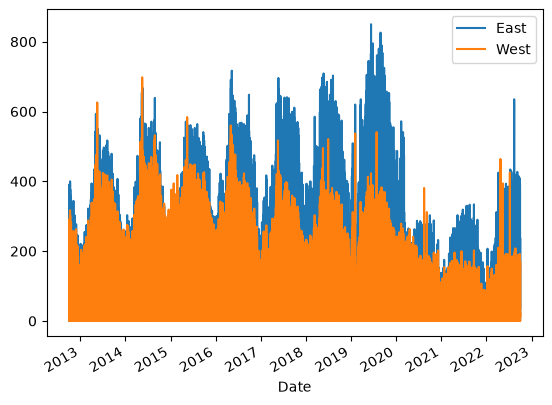

In [15]:
# un premier jet, pas terrible du tout
data[['East', 'West']].plot()
#On print data

<Axes: xlabel='Date'>

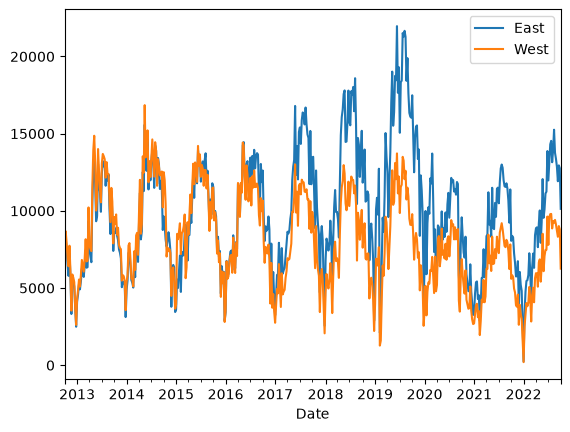

In [16]:
(data.resample("1W").sum())[['East', 'West']].plot()
#Dans la parenthèse à gauche on fait l'opération d'agrégation par semaine
#A droite c'est la partie pour print la courbe.

In [13]:
print(data.shape[0])
print(data.resample("1W").sum().shape[0])
#522*7*24=87696. On est dans des eaux respectables.


87600
522


In [17]:
#On réécrit data en sélectionnant les index à l'aide d'un masque demandant les dates avant 2017
data = data[data.index <= "2017-12-31 23:59:59"]


<Axes: xlabel='Date'>

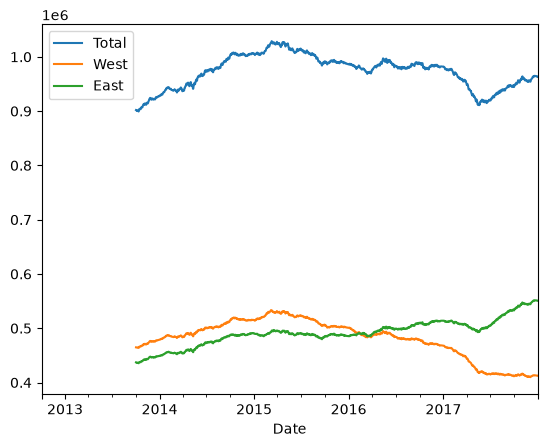

In [18]:
(data.resample("1D").sum().rolling(365).sum()).plot()
#On fait cette moyenne journalière sur l'année et puis on plot


<Axes: xlabel='time'>

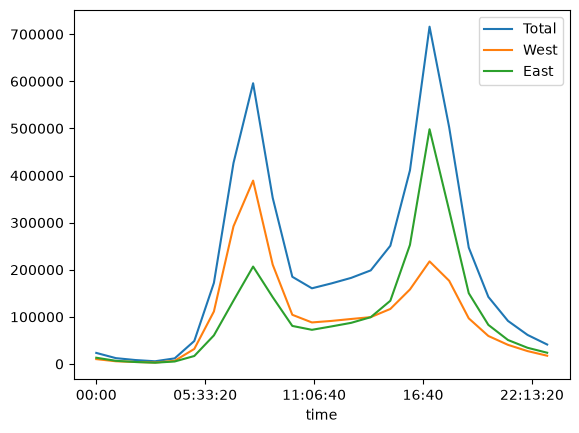

In [15]:
data.groupby(data.index.time).sum().plot()
#On compte en regroupant par heure, puis on plot

In [19]:
pivoted=data.pivot_table("Total",index=data.index.time,columns=data.index.date)
#On construit le pivot en pivotant selon les heures et les dates.

In [20]:
pivoted.shape

(24, 1916)

<Axes: xlabel='time'>

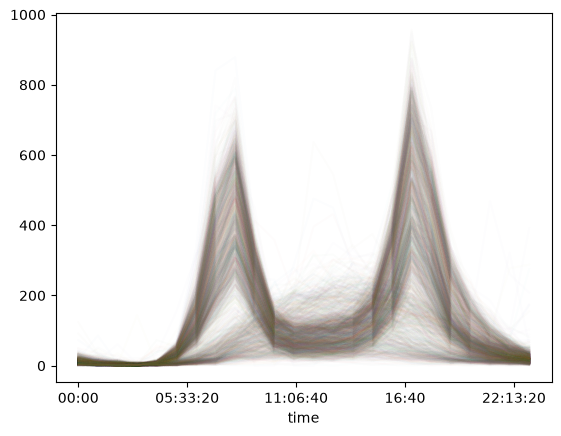

In [ ]:
pivoted.plot(legend=False,alpha=0.01)
#On plot sans la légende, et avec un facteur de transparence de 0.01

In [21]:
pca_input=pivoted.T.fillna(0)
#On transpose la matrice et on remplace les NaN par des 0

In [22]:
from sklearn.decomposition import PCA

In [31]:
pca_output=PCA(n_components=2).fit_transform(pca_input)

In [24]:
from sklearn.mixture import GaussianMixture


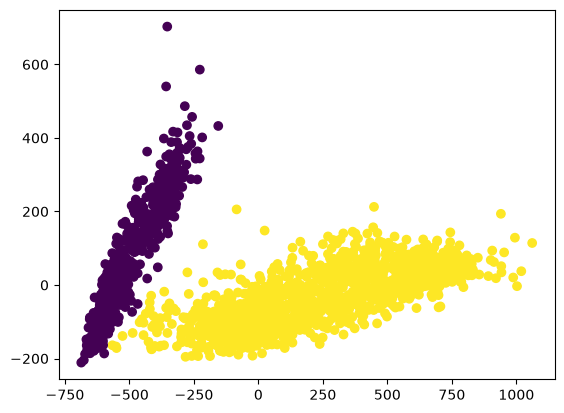

In [45]:
label=GaussianMixture(n_components=2).fit_predict(pca_output)
#On approche par une gaussienne prédisant dans lequel des deux groupes l'on se trouve.
plt.scatter(pca_output[:,0],pca_output[:,1],c=label)
#On plot alors le nuage de point pca_output précédent, mais en coloriant grâce à la gaussienne précédente.

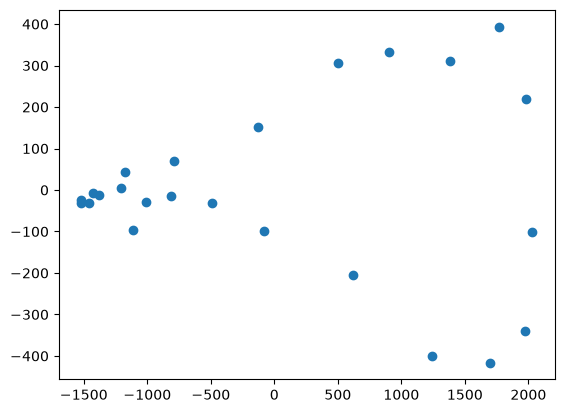

In [46]:
g0=pivoted.loc[:, label == 0]
#On sélectionne les points de label 0
pca_o0=PCA(n_components=2).fit_transform(g0)
#On le transforme pour l'afficher
plt.scatter(pca_o0[:,0],pca_o0[:,1])
#On l'affiche

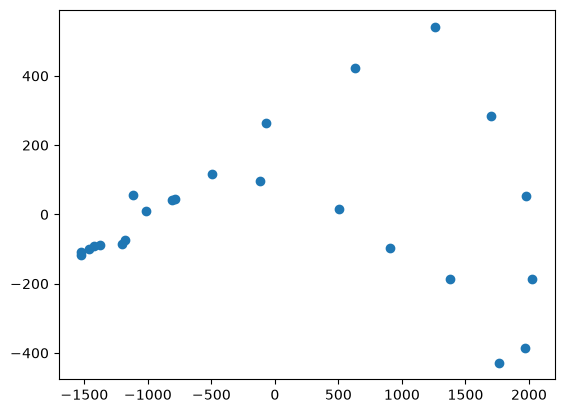

In [ ]:
g1=pivoted.loc[:, label == 1]
pca_o1=PCA(n_components=2).fit_transform(g1)
plt.scatter(pca_o1[:,0],pca_o1[:,1])
#même chose que précédement mai avec label==1

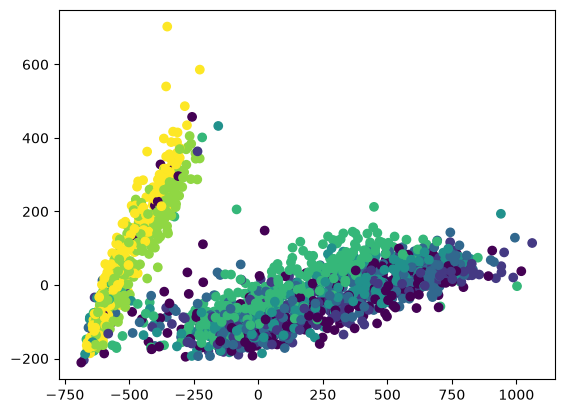

In [49]:
jours=pd.DatetimeIndex(pivoted.columns).dayofweek
#On récupère ainsi les jours de la semaine
plt.scatter(pca_output[:,0],pca_output[:,1],c=jours)
#Grâce à ces jours, on peut colorier comme il faut comme précédement en fonction des labels de la gaussienne.

In [ ]:
dates = pd.DatetimeIndex(pivoted.columns)
#On s'empare des dates
dates_bizarres=dates[(label==1)&(jours<5)]
#On sélectionnne les dates bizarres avec un masque
pivoted[dates_bizarres]
#On les renvoie

,2012-10-03,2012-10-04,2012-10-05,2012-10-08,2012-10-09,2012-10-10,2012-10-11,2012-10-12,2012-10-15,2012-10-16,...,2017-12-14,2017-12-15,2017-12-18,2017-12-19,2017-12-20,2017-12-21,2017-12-22,2017-12-27,2017-12-28,2017-12-29
00:00:00,13.0,18.0,11.0,9.0,12.0,15.0,21.0,17.0,7.0,10.0,...,7.0,9.0,1.0,2.0,7.0,9.0,12.0,4.0,2.0,11.0
01:00:00,10.0,3.0,8.0,4.0,3.0,3.0,10.0,13.0,3.0,5.0,...,4.0,10.0,2.0,2.0,4.0,1.0,0.0,2.0,0.0,2.0
02:00:00,2.0,9.0,7.0,5.0,4.0,3.0,13.0,5.0,5.0,3.0,...,3.0,3.0,1.0,3.0,0.0,3.0,0.0,0.0,2.0,2.0
03:00:00,5.0,3.0,4.0,5.0,8.0,4.0,2.0,7.0,3.0,5.0,...,3.0,4.0,3.0,2.0,4.0,4.0,3.0,1.0,2.0,2.0
04:00:00,7.0,8.0,9.0,5.0,9.0,5.0,12.0,5.0,6.0,5.0,...,3.0,6.0,6.0,8.0,8.0,4.0,6.0,4.0,8.0,5.0
05:00:00,31.0,26.0,25.0,23.0,31.0,25.0,12.0,14.0,26.0,29.0,...,36.0,27.0,20.0,23.0,32.0,28.0,20.0,17.0,21.0,15.0
06:00:00,155.0,142.0,105.0,137.0,153.0,149.0,43.0,87.0,93.0,122.0,...,97.0,62.0,83.0,65.0,87.0,67.0,54.0,42.0,43.0,35.0
07:00:00,352.0,319.0,319.0,327.0,368.0,340.0,304.0,183.0,225.0,256.0,...,253.0,191.0,177.0,132.0,204.0,128.0,102.0,58.0,83.0,56.0
08:00:00,437.0,418.0,370.0,457.0,462.0,435.0,404.0,268.0,327.0,357.0,...,373.0,298.0,278.0,175.0,282.0,239.0,120.0,118.0,117.0,70.0
09:00:00,276.0,241.0,212.0,278.0,275.0,255.0,189.0,145.0,203.0,207.0,...,204.0,154.0,169.0,122.0,163.0,140.0,81.0,63.0,83.0,39.0
